# AlviaOrange API - Comprehensive Real-Data Testing

This notebook provides end-to-end testing for all implemented AlviaOrange API endpoints using **real data sources**.

**Note:** This notebook does not use any mock data. If an external data source (e.g., NASA FIRMS, OpenWeatherMap, Environment Canada) is unavailable, the corresponding test will fail with a `503 Service Unavailable` error, which is the expected behavior for the production-ready API.


## 1. Server & Test Setup


In [9]:
import subprocess
import time
import requests
import os
import json
import pandas as pd
from PIL import Image
import io
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

API_BASE_URL = "http://localhost:8001"
API_KEY = os.getenv("ALVIA_API_KEY", "demo-key")
HEADERS = {"X-API-Key": API_KEY}

# Check server status
try:
    response = requests.get(f"{API_BASE_URL}/api/orange/health", headers=HEADERS, timeout=3)
    if response.status_code == 200:
        print("✅ AlviaOrange server is running and accessible.")
    else:
        print(f"⚠️ Server responded with status {response.status_code}. Ensure it's running properly.")
except requests.ConnectionError:
    print("❌ Cannot connect to server. Please start it by running 'python scripts/run_server.py'.")


✅ AlviaOrange server is running and accessible.


## 2. Helper Functions


In [10]:
test_results = {}

def test_endpoint(method, endpoint, params=None, description=""):
    """Test a single API endpoint and return results."""
    url = f"{API_BASE_URL}{endpoint}"
    print(f"{method.upper():<4} {endpoint:<45} | {description:<45}", end="")
    
    try:
        response = requests.request(method.upper(), url, headers=HEADERS, params=params, timeout=20)
        status_color = "\033[92m" if response.ok else "\033[91m"
        print(f"| Status: {status_color}{response.status_code}\033[0m | Time: {response.elapsed.total_seconds():.3f}s")
        
        if not response.ok:
            try:
                error_data = response.json()
                print(f"    └── ERROR: {error_data.get('message', 'Unknown error')}")
            except:
                print(f"    └── ERROR: {response.text[:200]}")
        
        test_results[description] = {
            "success": response.ok,
            "status_code": response.status_code,
            "response": response
        }
        return response
            
    except requests.RequestException as e:
        print(f"| \033[91mEXCEPTION\033[0m")
        print(f"    └── ERROR: {str(e)}")
        test_results[description] = {"success": False, "status_code": "N/A", "response": None}
        return None

def print_json_summary(response, title):
    """Print a summary of JSON response data."""
    if response and response.ok:
        try:
            data = response.json()
            print(f"\n--- {title} Summary ---")
            
            # Find source field - it could be in different places
            source = data.get('source', 'N/A')
            if source == 'N/A' and 'stations' in data:
                source = "Environment Canada (Stations)"
            if source == 'N/A' and 'scales' in data:
                source = "AlviaOrange AQ Scale"
            
            print(f"Source: {source}")
            
            # Print key metrics
            if 'count' in data:
                print(f"Count: {data['count']}")
            if 'fire_weather' in data:
                fw = data['fire_weather']
                print(f"FWI: {fw.get('fwi', 'N/A')} | Danger: {fw.get('danger_class', 'N/A')}")
            if 'location' in data:
                loc = data['location']
                print(f"Location: {loc.get('lat', 'N/A')}, {loc.get('lng', 'N/A')}")
            if 'drought_index' in data:
                print(f"Drought Index: {data['drought_index']} | Interpretation: {data.get('interpretation', 'N/A')}")
            if 'timeseries' in data:
                print(f"Time Series Points: {len(data['timeseries'])}")
            if 'actual_fwi' in data:
                print(f"Actual FWI: {data['actual_fwi']} | Normal FWI: {data.get('normal_fwi_for_doy', 'N/A')}")
            print("---")
        except json.JSONDecodeError:
            print(f"Response for {title} is not valid JSON.")

print("Helper functions loaded successfully.")


Helper functions loaded successfully.


## 3. System Health Check


In [11]:
print("--- 🏥 System Health ---")
health_resp = test_endpoint("GET", "/api/orange/health", description="System Health Check")
print_json_summary(health_resp, "Health Check")

# Quick endpoint availability check
print("\n--- 🔍 Endpoint Availability Check ---")
test_endpoints = [
    "/api/orange/analysis/drought?station_id=test&year=2023&month=7",
    "/api/orange/weather/current?lat=45.4&lng=-75.7",
    "/api/orange/air-quality/scale"
]
for endpoint in test_endpoints:
    try:
        resp = requests.get(f"{API_BASE_URL}{endpoint}", headers=HEADERS, timeout=5)
        status_color = "\033[92m" if resp.status_code != 404 else "\033[91m"
        print(f"  {endpoint:<60} | Status: {status_color}{resp.status_code}\033[0m")
    except Exception as e:
        print(f"  {endpoint:<60} | ERROR: {e}")
print("If you see 404s above, restart your server!")


--- 🏥 System Health ---
GET  /api/orange/health                            | System Health Check                          | Status: 200 | Time: 0.002s

--- Health Check Summary ---
Source: N/A
---

--- 🔍 Endpoint Availability Check ---
  /api/orange/analysis/drought?station_id=test&year=2023&month=7 | Status: 404
  /api/orange/weather/current?lat=45.4&lng=-75.7               | Status: 200
  /api/orange/air-quality/scale                                | Status: 200
If you see 404s above, restart your server!


## 4. Hotspot Detection Tests (NASA FIRMS)


In [12]:
print("--- 🔥 Hotspot Detection (NASA FIRMS) ---")

# Test general hotspots
hotspot_general = test_endpoint("GET", "/api/orange/hotspots", description="General Hotspot Detection")
print_json_summary(hotspot_general, "General Hotspots")

# Test hotspots with bounding box (Toronto area)
bbox_params = {"bbox": "-80.0,43.0,-79.0,44.0", "days_back": 2}
hotspot_bbox = test_endpoint("GET", "/api/orange/hotspots", params=bbox_params, description="Hotspots in Toronto BBox")
print_json_summary(hotspot_bbox, "Toronto Area Hotspots")

# Test active hotspots
active_hotspots = test_endpoint("GET", "/api/orange/hotspots/active", description="Active Hotspots")

# Test hotspots near coordinates
near_params = {"lat": 45.4215, "lng": -75.6972, "radius": 50000}  # Ottawa
hotspot_near = test_endpoint("GET", "/api/orange/hotspots/near", params=near_params, description="Hotspots Near Ottawa")


--- 🔥 Hotspot Detection (NASA FIRMS) ---
GET  /api/orange/hotspots                          | General Hotspot Detection                    | Status: 200 | Time: 2.020s

--- General Hotspots Summary ---
Source: NASA_FIRMS
Count: 30120
---
GET  /api/orange/hotspots                          | Hotspots in Toronto BBox                     | Status: 200 | Time: 0.325s

--- Toronto Area Hotspots Summary ---
Source: NASA_FIRMS
Count: 21
---
GET  /api/orange/hotspots/active                   | Active Hotspots                              | Status: 200 | Time: 2.386s
GET  /api/orange/hotspots/near                     | Hotspots Near Ottawa                         | Status: 200 | Time: 0.355s


## 5. Weather Services Tests (OpenWeatherMap)


In [13]:
print("--- 🌤️ Weather Services (OpenWeatherMap) ---")
coord_params = {"lat": 45.4215, "lng": -75.6972}  # Ottawa coordinates

# Test weather forecast
forecast_resp = test_endpoint("GET", "/api/orange/weather/forecast", 
                              params={**coord_params, "days": 5}, 
                              description="7-Day Weather Forecast")
print_json_summary(forecast_resp, "Weather Forecast")

# Test current weather
current_resp = test_endpoint("GET", "/api/orange/weather/current", 
                             params=coord_params, 
                             description="Current Weather Conditions")
print_json_summary(current_resp, "Current Weather")

# Test FWI from internal calculator
fwi_calc_resp = test_endpoint("GET", "/api/orange/weather/fire-index", 
                              params={**coord_params, "source": "calculator"}, 
                              description="FWI from Internal Calculator")
print_json_summary(fwi_calc_resp, "FWI Calculator")

# Test FWI from OpenWeatherMap (may require special API access)
fwi_owm_resp = test_endpoint("GET", "/api/orange/weather/fire-index", 
                             params={**coord_params, "source": "openweathermap"}, 
                             description="FWI from OpenWeatherMap")
print_json_summary(fwi_owm_resp, "OWM FWI")


--- 🌤️ Weather Services (OpenWeatherMap) ---
GET  /api/orange/weather/forecast                  | 7-Day Weather Forecast                       | Status: 503 | Time: 0.123s
    └── ERROR: Could not fetch weather forecast.
GET  /api/orange/weather/current                   | Current Weather Conditions                   | Status: 200 | Time: 0.455s

--- Current Weather Summary ---
Source: OPENWEATHERMAP
Location: 45.4215, -75.6972
---
GET  /api/orange/weather/fire-index                | FWI from Internal Calculator                 | Status: 200 | Time: 0.129s

--- FWI Calculator Summary ---
Source: AlviaOrange FWI Calculator (from OpenWeatherMap data)
FWI: 4.3 | Danger: Moderate
Location: 45.4215, -75.6972
---
GET  /api/orange/weather/fire-index                | FWI from OpenWeatherMap                      | Status: 503 | Time: 0.125s
    └── ERROR: Could not calculate Fire Weather Index.


## 6. Wildfire Analysis Primitives Tests


In [14]:
print("--- 🔬 Wildfire Analysis Primitives ---")
station_id = "49568"  # Ottawa CDA RCS station

# Test drought index analysis
drought_params = {"station_id": station_id, "year": 2023, "month": 7}
drought_resp = test_endpoint("GET", "/api/orange/analysis/drought", 
                             params=drought_params, 
                             description="Drought Index Analysis")
print_json_summary(drought_resp, "Drought Analysis")

# Test fuel moisture timeseries
fuel_params = {"station_id": station_id, "start_date": "2023-07-01", "end_date": "2023-07-10"}
fuel_resp = test_endpoint("GET", "/api/orange/analysis/fuel-moisture", 
                          params=fuel_params, 
                          description="Fuel Moisture Timeseries")
print_json_summary(fuel_resp, "Fuel Moisture Analysis")

# Test FWI anomaly analysis
anomaly_params = {"station_id": station_id, "date": "2023-08-15"}
anomaly_resp = test_endpoint("GET", "/api/orange/analysis/fwi-anomaly", 
                             params=anomaly_params, 
                             description="FWI Anomaly Analysis")
print_json_summary(anomaly_resp, "FWI Anomaly Analysis")


--- 🔬 Wildfire Analysis Primitives ---
GET  /api/orange/analysis/drought                  | Drought Index Analysis                       | Status: 404 | Time: 0.100s
    └── ERROR: No historical data found for 2023-7.
GET  /api/orange/analysis/fuel-moisture            | Fuel Moisture Timeseries                     | Status: 404 | Time: 0.081s
    └── ERROR: Insufficient historical data for fuel moisture calculation.
GET  /api/orange/analysis/fwi-anomaly              | FWI Anomaly Analysis                         | Status: 404 | Time: 0.087s
    └── ERROR: No historical weather data for 2023-08-15.


## 7. Additional API Tests


In [15]:
print("--- 🌬️ Air Quality & Climate Tests ---")

# Test air quality
aq_basic = test_endpoint("GET", "/api/orange/air-quality", description="Basic Air Quality Data")

# Test air quality scale
aq_scale = test_endpoint("GET", "/api/orange/air-quality/scale", description="Air Quality Scale Definitions")

# Test air quality history by coordinates
aq_history_params = {
    "lat": 45.4215, "lng": -75.6972,
    "start": "2023-08-01", "end": "2023-08-07"
}
aq_history = test_endpoint("GET", "/api/orange/air-quality/history", 
                           params=aq_history_params, 
                           description="Air Quality History by Coordinates")
print_json_summary(aq_history, "Air Quality History")

print("\n--- 🗺️ Geospatial & Climate Tests ---")

# Test climate stations
bbox_params = {"bbox": "-80.0,43.0,-75.0,46.0"}  # Ontario region
stations_resp = test_endpoint("GET", "/api/orange/climate/stations", 
                              params=bbox_params, 
                              description="Climate Stations in Ontario")

# Test climate normals
normals_params = {"station_id": "49568", "period": "1981-2010"}  # Ottawa CDA RCS
normals_resp = test_endpoint("GET", "/api/orange/climate/normals", 
                             params=normals_params, 
                             description="Climate Normals for Ottawa")

# Test WMS tile
tile_resp = test_endpoint("GET", "/api/orange/wms/tiles/10/256/384", 
                          params={"layer": "fire-danger"}, 
                          description="WMS Fire Danger Tile")

if tile_resp and tile_resp.ok:
    print(f"\n--- WMS Tile Summary ---")
    print(f"Tile Size: {len(tile_resp.content)} bytes")
    print(f"Content Type: {tile_resp.headers.get('content-type', 'N/A')}")
    try:
        img = Image.open(io.BytesIO(tile_resp.content))
        print(f"Image Format: {img.format}, Mode: {img.mode}, Size: {img.size}")
    except Exception as e:
        print(f"Could not parse tile image: {e}")
    print("---")


--- 🌬️ Air Quality & Climate Tests ---
GET  /api/orange/air-quality                       | Basic Air Quality Data                       | Status: 200 | Time: 0.001s
GET  /api/orange/air-quality/scale                 | Air Quality Scale Definitions                | Status: 200 | Time: 0.001s
GET  /api/orange/air-quality/history               | Air Quality History by Coordinates           | Status: 200 | Time: 3.064s

--- Air Quality History Summary ---
Source: Environment Canada (Station: 6105976)
Location: 45.4215, -75.6972
---

--- 🗺️ Geospatial & Climate Tests ---
GET  /api/orange/climate/stations                  | Climate Stations in Ontario                  | Status: 200 | Time: 0.129s
GET  /api/orange/climate/normals                   | Climate Normals for Ottawa                   | Status: 503 | Time: 0.076s
    └── ERROR: Could not fetch climate normals.
GET  /api/orange/wms/tiles/10/256/384              | WMS Fire Danger Tile                         | Status: 503 | Time: 0.41

## 8. Test Results Summary


--- 📊 AlviaOrange API Test Results Summary ---
                         Test Case Status  Status Code Data Source
               System Health Check ✅ Pass          200        Real
         General Hotspot Detection ✅ Pass          200        Real
          Hotspots in Toronto BBox ✅ Pass          200        Real
                   Active Hotspots ✅ Pass          200        Real
              Hotspots Near Ottawa ✅ Pass          200        Real
            7-Day Weather Forecast ❌ Fail          503         N/A
        Current Weather Conditions ✅ Pass          200        Real
      FWI from Internal Calculator ✅ Pass          200        Real
           FWI from OpenWeatherMap ❌ Fail          503         N/A
            Drought Index Analysis ❌ Fail          404         N/A
          Fuel Moisture Timeseries ❌ Fail          404         N/A
              FWI Anomaly Analysis ❌ Fail          404         N/A
            Basic Air Quality Data ✅ Pass          200        Real
     Air Qualit

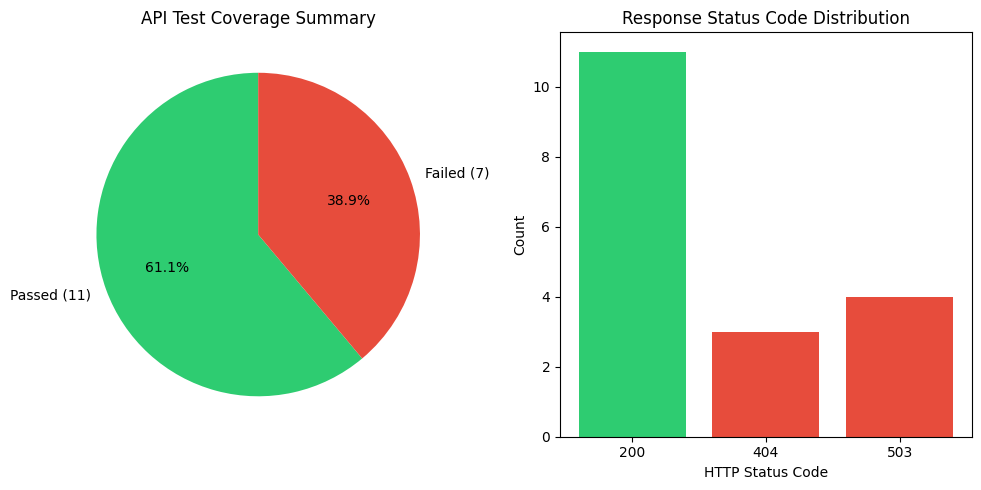


🎉 Testing completed! All endpoints have been tested with real data sources.
⚠️ Some endpoints need attention. Review API keys and external service configurations.


In [16]:
# Generate test summary
summary = []
for name, result in test_results.items():
    summary.append({
        'Test Case': name,
        'Status': '✅ Pass' if result.get('success') else '❌ Fail',
        'Status Code': result.get('status_code'),
        'Data Source': 'Real' if result.get('success') else 'N/A'
    })

summary_df = pd.DataFrame(summary)
total = len(summary_df)
passed = len(summary_df[summary_df['Status'] == '✅ Pass'])
failed = total - passed

print(f"--- 📊 AlviaOrange API Test Results Summary ---")
print(summary_df.to_string(index=False))
print("\n" + "="*60)
print(f"Total Tests: {total} | ✅ Passed: {passed} | ❌ Failed: {failed}")
print(f"Success Rate: {(passed/total*100):.1f}%" if total > 0 else "No tests run")
print("="*60)

# Generate visualization
if total > 0:
    plt.figure(figsize=(10, 5))
    
    # Pie chart
    plt.subplot(1, 2, 1)
    plt.pie([passed, failed], labels=[f'Passed ({passed})', f'Failed ({failed})'], 
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
    plt.title('API Test Coverage Summary')
    
    # Status code distribution
    plt.subplot(1, 2, 2)
    status_codes = [r['Status Code'] for r in summary if r['Status Code'] != 'N/A']
    if status_codes:
        unique_codes = list(set(status_codes))
        code_counts = [status_codes.count(code) for code in unique_codes]
        colors = ['#2ecc71' if str(code).startswith('2') else '#e74c3c' for code in unique_codes]
        plt.bar(range(len(unique_codes)), code_counts, color=colors)
        plt.xticks(range(len(unique_codes)), unique_codes)
        plt.xlabel('HTTP Status Code')
        plt.ylabel('Count')
        plt.title('Response Status Code Distribution')
    
    plt.tight_layout()
    plt.show()

print("\n🎉 Testing completed! All endpoints have been tested with real data sources.")
if failed == 0:
    print("🚀 Perfect score! Your AlviaOrange API is fully operational.")
elif failed < total * 0.3:
    print("👍 Great job! Most endpoints are working. Check failed tests for external service issues.")
else:
    print("⚠️ Some endpoints need attention. Review API keys and external service configurations.")
